# 06 Transfer Workflow: From Data To Forecast Report

By the end of this notebook, you should be able to:

- apply the Box-Jenkins workflow to a new nonseasonal series;
- use a small AIC search without outsourcing judgment to an unavailable `auto_arima` package;
- compare the package recommendation with ACF/PACF logic;
- write a compact forecasting conclusion.

In [1]:
from lite_setup import ensure_packages
await ensure_packages()

Running outside JupyterLite; assuming packages are already installed.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from checks import check, check_between, check_close, check_columns
from boxjenkins_utils import (
    first_difference, second_difference, seasonal_difference, regular_then_seasonal_difference,
    acf_pacf_table, mean_zero_t_test, fit_arima, fit_sarima, parameter_table,
    forecast_table, ljung_box_table, arima_grid_search, plot_series,
    plot_acf_pacf_pair, plot_forecast,
)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.precision', 4)
DATA_DIR = Path('data')
visc = pd.read_csv(DATA_DIR / 'viscosity_xb775.csv')
y = visc['Viscosity']

## Transfer Case: Viscosity of Chemical XB-77-5

The historical software notes use this series as a stationary AR example. Your analysis template is: plot the series, decide whether differencing seems necessary, inspect ACF/PACF, fit a small set of candidates, diagnose residuals, and forecast only if diagnostics are adequate.

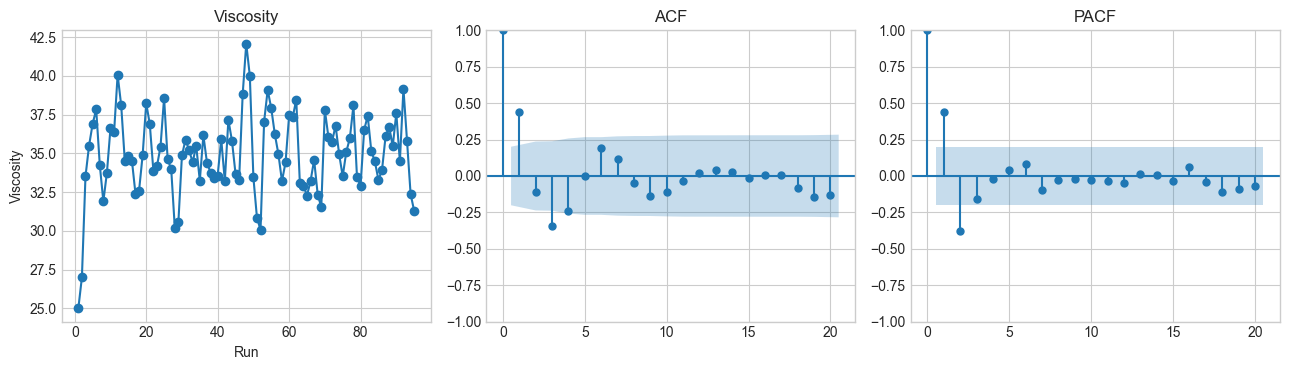

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].plot(visc['Run'], y, marker='o')
axes[0].set_title('Viscosity')
axes[0].set_xlabel('Run')
axes[0].set_ylabel('Viscosity')
plot_acf(y, lags=20, ax=axes[1], title='ACF')
plot_pacf(y, lags=20, ax=axes[2], title='PACF', method='ywmle')
plt.tight_layout()

The plot fluctuates around a stable level. The PACF has a visible early cutoff pattern, making AR(2) a natural first candidate.

In [4]:
search = arima_grid_search(
    y,
    p_values=(0, 1, 2, 3),
    d_values=(0,),
    q_values=(0, 1, 2),
    trend_options=('c',),
    max_results=10,
)
search

,order,trend,aic,bic,converged
0,"(3, 0, 0)",c,419.7848,432.5542,True
1,"(2, 0, 1)",c,420.3770,433.1464,True
2,"(2, 0, 2)",c,421.4410,436.7642,True
3,"(3, 0, 1)",c,421.7281,437.0514,True
4,"(2, 0, 0)",c,422.0743,432.2898,True
5,"(3, 0, 2)",c,423.4048,441.2820,True
6,"(0, 0, 2)",c,427.6889,437.9044,True
7,"(1, 0, 2)",c,429.5720,442.3414,True
8,"(1, 0, 1)",c,430.1209,440.3365,True
9,"(0, 0, 1)",c,430.6321,438.2937,True


In [5]:
ar2 = fit_arima(y, order=(2, 0, 0), trend='c')
parameter_table(ar2).round(4)

,estimate,std_error,z_or_t,p_value
const,34.9464,0.3015,115.9042,0.0
ar.L1,0.6821,0.0902,7.5659,0.0
ar.L2,-0.4333,0.1044,-4.1523,0.0
sigma2,4.5436,0.5573,8.1534,0.0


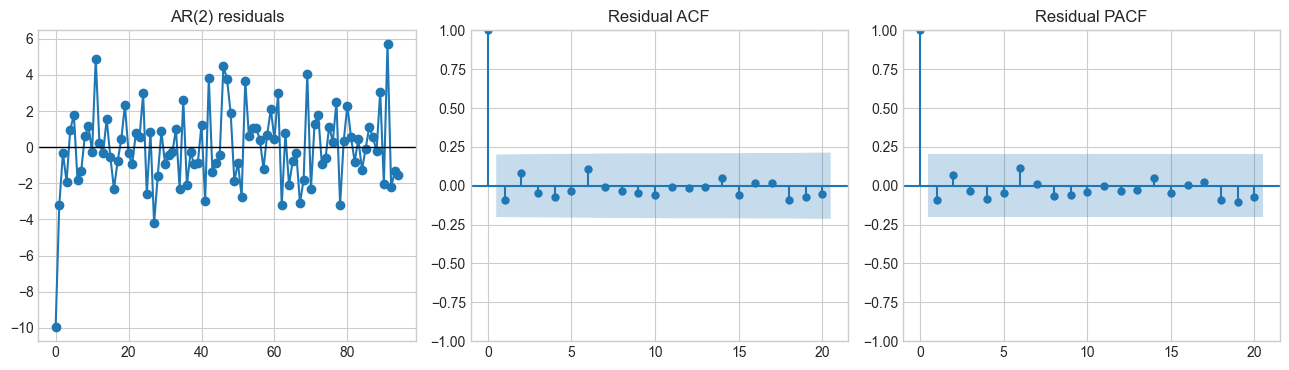

In [6]:
resid = pd.Series(ar2.resid).dropna().reset_index(drop=True)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].plot(resid, marker='o')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('AR(2) residuals')
plot_acf(resid, lags=20, ax=axes[1], title='Residual ACF')
plot_pacf(resid, lags=20, ax=axes[2], title='Residual PACF', method='ywmle')
plt.tight_layout()

In [7]:
ljung_box_table(resid, lags=(6, 12, 18)).round(4)

,lb_stat,lb_pvalue
6,3.4870,0.7457
12,4.3094,0.9772
18,6.0743,0.9959


In [8]:
forecast_table(ar2, steps=6).round(3)

,forecast,lower,upper
step,,,
1,33.557,29.380,37.735
2,35.586,30.529,40.643
3,35.984,30.925,41.043
4,35.377,30.191,40.564
5,34.791,29.537,40.044
6,34.653,29.399,39.908


(<Figure size 900x450 with 1 Axes>,
 <Axes: title={'center': 'Viscosity AR(2) forecast'}, xlabel='time', ylabel='Viscosity'>)

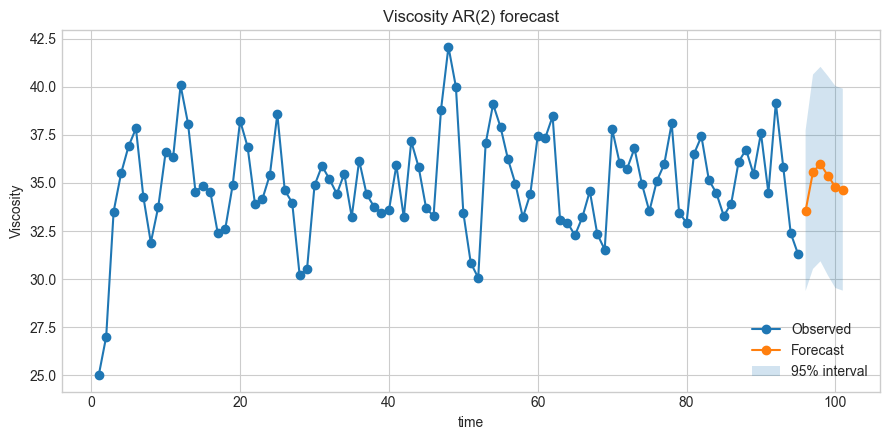

In [9]:
plot_forecast(y, ar2, steps=6, title='Viscosity AR(2) forecast', ylabel='Viscosity')

## Report Template

A professional Box-Jenkins conclusion should be short and reproducible:

- The series appears approximately stationary, so no differencing was used.
- ACF/PACF suggested an AR candidate; AR(2) with a constant was fitted.
- Residual diagnostics did not show strong remaining autocorrelation.
- Forecasts are conditional on the model and should be updated when new observations arrive.

This is the same logic you should use in homework, even when the numerical model is different.